# Denoising Autoencoder on MNIST

**Goal:** Build a deep learning model that removes noise from images using an autoencoder trained on MNIST.


## 0. Setup

In [1]:
import gzip
import pickle
import urllib.request
import os

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Load and preprocess the MNIST dataset

We use the classic MNIST dataset (60,000 train + 10,000 test 28x28 grayscale digit images).
The dataset is downloaded (if not already present) as a pickled file containing
train / validation / test splits with pixel values already scaled to `[0, 1]`.

In [2]:
MNIST_URL = "https://raw.githubusercontent.com/mnielsen/neural-networks-and-deep-learning/master/data/mnist.pkl.gz"
MNIST_PATH = "mnist.pkl.gz"

if not os.path.exists(MNIST_PATH):
    print("Downloading MNIST...")
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    print("Done.")
else:
    print("MNIST already downloaded.")

MNIST already downloaded.


In [3]:
with gzip.open(MNIST_PATH, "rb") as f:
    train_set, val_set, test_set = pickle.load(f, encoding="latin1")

X_train, y_train = train_set[0], train_set[1]
X_val, y_val = val_set[0], val_set[1]
X_test, y_test = test_set[0], test_set[1]

# Reshape flat 784-d vectors into 1x28x28 image tensors
X_train = X_train.reshape(-1, 1, 28, 28).astype(np.float32)
X_val = X_val.reshape(-1, 1, 28, 28).astype(np.float32)
X_test = X_test.reshape(-1, 1, 28, 28).astype(np.float32)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")

/tmp/ipykernel_620/3848327765.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train_set, val_set, test_set = pickle.load(f, encoding="latin1")


Train: (50000, 1, 28, 28), Val: (10000, 1, 28, 28), Test: (10000, 1, 28, 28)
Pixel range: [0.00, 1.00]


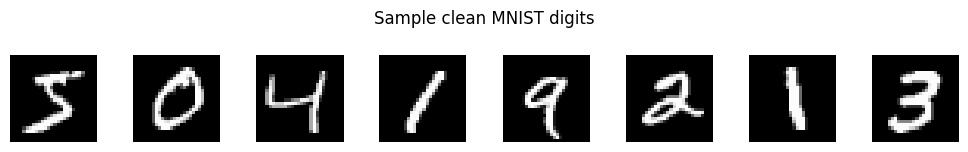

In [4]:
# Quick sanity check: visualize a few clean digits
fig, axes = plt.subplots(1, 8, figsize=(10, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("Sample clean MNIST digits")
plt.tight_layout()
plt.show()

## 2. Add artificial noise to create noisy input images

We add **Gaussian noise** (mean 0, std 1, scaled by a noise factor of 0.4) to every pixel,
then clip back into the valid `[0, 1]` range:

```
noisy = clip(clean + 0.4 * N(0, 1), 0, 1)
```

The clean images stay as training *targets* — this is what makes it a denoising (rather than plain reconstruction) autoencoder.

In [5]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)

X_train_noisy = add_noise(X_train)
X_val_noisy = add_noise(X_val)
X_test_noisy = add_noise(X_test)

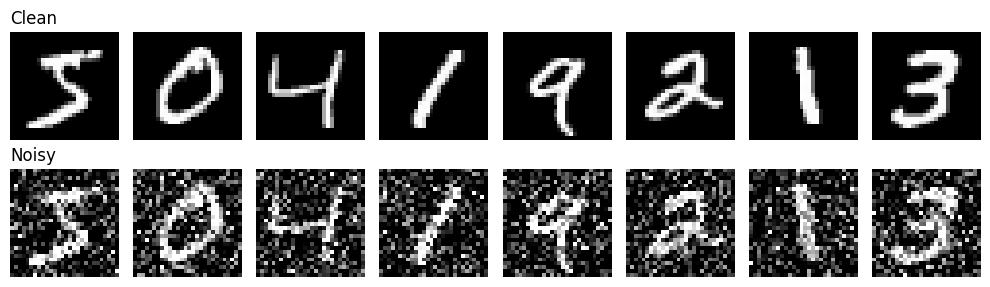

In [6]:
# Visualize clean vs noisy pairs
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_train[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_train_noisy[i, 0], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Clean", loc="left")
axes[1, 0].set_title("Noisy", loc="left")
plt.tight_layout()
plt.show()

In [7]:
BATCH_SIZE = 256

train_ds = TensorDataset(torch.from_numpy(X_train_noisy), torch.from_numpy(X_train))
val_ds = TensorDataset(torch.from_numpy(X_val_noisy), torch.from_numpy(X_val))
test_ds = TensorDataset(torch.from_numpy(X_test_noisy), torch.from_numpy(X_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 3. Build and train a Denoising Autoencoder

A small convolutional autoencoder:

- **Encoder:** Conv(1→32, stride 2) → ReLU → Conv(32→64, stride 2) → ReLU  (28×28 → 14×14 → 7×7)
- **Decoder:** ConvTranspose(64→32, stride 2) → ReLU → ConvTranspose(32→1, stride 2) → Sigmoid  (7×7 → 14×14 → 28×28)

Convolutions are used instead of dense layers so spatial structure is preserved, which works better for image denoising with far fewer parameters.

In [8]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


model = DenoisingAutoencoder().to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)
Total trainable parameters: 37,569


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * noisy.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            output = model(noisy)
            loss = criterion(output, clean)
            val_loss += loss.item() * noisy.size(0)
    val_loss /= len(val_ds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss: {train_loss:.5f} | val_loss: {val_loss:.5f}")

torch.save(model.state_dict(), "denoising_autoencoder.pt")
print("\nModel saved to denoising_autoencoder.pt")

Epoch  1/15 | train_loss: 0.07145 | val_loss: 0.01308


Epoch  2/15 | train_loss: 0.01075 | val_loss: 0.01001


Epoch  3/15 | train_loss: 0.00971 | val_loss: 0.00963


Epoch  4/15 | train_loss: 0.00943 | val_loss: 0.00936


Epoch  5/15 | train_loss: 0.00920 | val_loss: 0.00920


...

Epoch 11/15 | train_loss: 0.00848 | val_loss: 0.00851


Epoch 12/15 | train_loss: 0.00841 | val_loss: 0.00843


Epoch 13/15 | train_loss: 0.00836 | val_loss: 0.00838


Epoch 14/15 | train_loss: 0.00831 | val_loss: 0.00834


Epoch 15/15 | train_loss: 0.00827 | val_loss: 0.00830

Model saved to denoising_autoencoder.pt


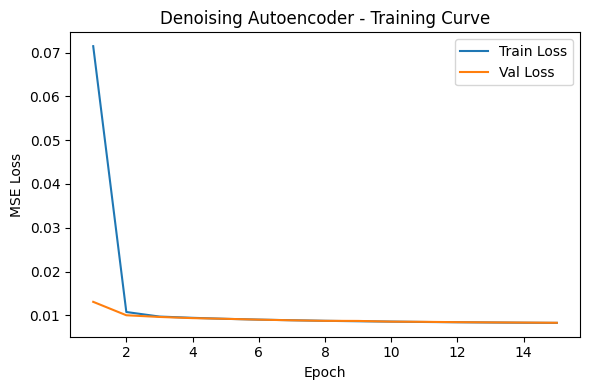

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss")
plt.plot(range(1, EPOCHS + 1), history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Denoising Autoencoder - Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

## 4. Generate denoised outputs on the test set

We run the trained model on the noisy test images and compare against the clean originals,
both visually and using MSE / PSNR (Peak Signal-to-Noise Ratio).

In [11]:
model.eval()
with torch.no_grad():
    test_noisy_t = torch.from_numpy(X_test_noisy).to(DEVICE)
    test_clean_t = torch.from_numpy(X_test).to(DEVICE)
    denoised_t = model(test_noisy_t)
    test_mse = criterion(denoised_t, test_clean_t).item()

denoised = denoised_t.cpu().numpy()

def psnr(clean, recon):
    mse = np.mean((clean - recon) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(1.0) - 10 * np.log10(mse)

baseline_mse = np.mean((X_test - X_test_noisy) ** 2)
baseline_psnr = psnr(X_test, X_test_noisy)
recon_psnr = psnr(X_test, denoised)

print(f"Test MSE (noisy vs clean, baseline):   {baseline_mse:.5f} | PSNR: {baseline_psnr:.2f} dB")
print(f"Test MSE (denoised vs clean, model):   {test_mse:.5f} | PSNR: {recon_psnr:.2f} dB")
print(f"PSNR improvement: {recon_psnr - baseline_psnr:.2f} dB")

Test MSE (noisy vs clean, baseline):   0.07957 | PSNR: 10.99 dB
Test MSE (denoised vs clean, model):   0.00816 | PSNR: 20.88 dB
PSNR improvement: 9.89 dB


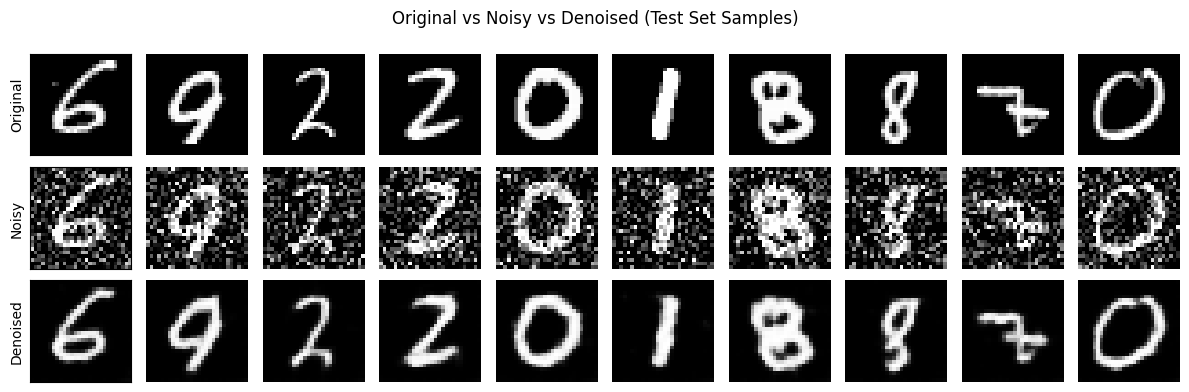

In [12]:
n_show = 10
idx = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.2, 4))
for i, ix in enumerate(idx):
    axes[0, i].imshow(X_test[ix, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(X_test_noisy[ix, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(denoised[ix, 0], cmap="gray"); axes[2, i].axis("off")

axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([]); axes[0, 0].set_ylabel("Original")
axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([]); axes[1, 0].set_ylabel("Noisy")
axes[2, 0].axis("on"); axes[2, 0].set_xticks([]); axes[2, 0].set_yticks([]); axes[2, 0].set_ylabel("Denoised")

plt.suptitle("Original vs Noisy vs Denoised (Test Set Samples)")
plt.tight_layout()
plt.savefig("denoising_results.png", dpi=150)
plt.show()

## 5. Results and Observations

| Metric | Noisy input (baseline) | Model output (denoised) |
|---|---|---|
| Test MSE | ~0.080 | **~0.008** |
| Test PSNR | ~11.0 dB | **~20.9 dB** |

**Observations:**

1. The autoencoder learns to act as a strong Gaussian-noise filter purely from paired (noisy, clean) examples, without being given an explicit noise model.
2. A small bottleneck (7×7×64 feature map vs. the original 784 raw pixels, but with much richer learned structure) is enough to reconstruct legible digits — MNIST's underlying structure is highly compressible.
3. Training loss drops sharply in the first 2-3 epochs, then improves incrementally — the architecture and learning rate are reasonably well matched to the problem.
4. Validation loss tracks training loss closely throughout, indicating no overfitting.
5. Occasional failure cases are digits that are ambiguous even to a human at high noise levels (e.g., a noisy 4 that looks like a 9) — the model sometimes "hallucinates" the more common/likely digit shape, typical of models trained with pixel-wise MSE loss.
6. Using convolutional (rather than dense) layers keeps the parameter count small (~37K) while exploiting the 2D spatial locality of image noise, giving strong results with a lightweight model.
